Title:
Data-Driven Social Media Engagement and Virality Prediction System using Machine Learning and NLP

Problem Statement

In today’s digital ecosystem, social media platforms generate massive amounts of user engagement data, yet predicting which content will become viral remains largely intuitive and uncertain. Content creators and marketers often rely on guesswork rather than data-driven insights to optimize engagement.

This project aims to develop a data-driven system that analyzes social media content performance using machine learning and natural language processing techniques. The system focuses on identifying patterns in engagement metrics, content types, and audience sentiment to predict whether a post is likely to go viral.

The key challenge addressed in this project is to build a predictive model without relying on direct engagement indicators that cause data leakage, thereby ensuring realistic and generalizable predictions. Additionally, the project explores the trade-offs between accuracy and class balance in imbalanced datasets.

OBJECTIVE

To analyze social media engagement data

To perform sentiment analysis using NLP

To build a machine learning model for virality prediction

To avoid data leakage and ensure realistic predictions

To evaluate model performance using multiple metrics

Import Libraries

In [4]:
import pandas as pd
import numpy as np
from textblob import TextBlob
df = pd.read_csv("social_media_viral_content_dataset.csv")
print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
     post_id        platform content_type       topic language  region  \
0  SM_100000       Instagram         text      Sports       ur      UK   
1  SM_100001       Instagram     carousel      Sports       ur  Brazil   
2  SM_100002  YouTube Shorts        video  Technology       ur      UK   
3  SM_100003               X         text    Politics       ur      US   
4  SM_100004  YouTube Shorts         text   Education       es      US   

         post_datetime                         hashtags    views   likes  \
0  2024-12-10 00:00:00              #tech #funny #music  2319102  122058   
1  2024-10-13 00:00:00  #news #fyp #funny #ai #trending  2538464  110368   
2  2024-05-03 00:00:00                        #ai #news  1051176   87598   
3  2024-08-04 00:00:00                       #ai #funny  5271440  329465   
4  2024-03-28 00:00:00     #news #ai #viral #funny #fyp  3186256  199141   

   comments  shares  engagement_rate  sentiment_score  is_viral  
0   

Basic Data Understanding

In [5]:
# Dataset Info
df.info()

# Missing Values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 234.5+ KB


,0
post_id,0
platform,0
content_type,0
topic,0
language,0
region,0
post_datetime,0
hashtags,0
views,0
likes,0


Data Cleaning

In [6]:
# Remove missing values
df = df.dropna()
# Remove duplicates if any
df = df.drop_duplicates()
print("\nData cleaned successfully")


Data cleaned successfully


In [72]:
df["engagement_level"] = pd.cut(
    df["likes"],
    bins=[0, 2000, 8000, df["likes"].max()],
    labels=["low", "medium", "high"]
)

In [73]:
df_encoded = pd.get_dummies(df, columns=["platform", "content_type", "topic", "engagement_level"], drop_first=True)

In [74]:
df["likes_per_view"] = df["likes"] / (df["views"] + 1)
df["comments_per_view"] = df["comments"] / (df["views"] + 1)
df["shares_per_view"] = df["shares"] / (df["views"] + 1)

Feature Engineering
Create meaningful text for NLP

In [75]:
# Generate meaningful text for NLP
def generate_text(row):
    if row["likes"] > 10000:
        tone = "amazing and exciting"
    elif row["likes"] < 2000:
        tone = "boring and disappointing"
    else:
        tone = "average and okay"
    return f"This is a {tone} {row['topic']} post on {row['platform']} in {row['content_type']} format"
df["text"] = df.apply(generate_text, axis=1)
print("\nText Feature Created Successfully")
print(df[["text"]].head())


Text Feature Created Successfully
                                                text
0  This is a amazing and exciting Sports post on ...
1  This is a amazing and exciting Sports post on ...
2  This is a amazing and exciting Technology post...
3  This is a amazing and exciting Politics post o...
4  This is a amazing and exciting Education post ...


Sentiment Analysis

In [76]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"
df["predicted_sentiment"] = df["text"].apply(get_sentiment)
print("\nSentiment Analysis Completed")
print(df[["text", "predicted_sentiment"]].head())


Sentiment Analysis Completed
                                                text predicted_sentiment
0  This is a amazing and exciting Sports post on ...            Positive
1  This is a amazing and exciting Sports post on ...            Positive
2  This is a amazing and exciting Technology post...            Positive
3  This is a amazing and exciting Politics post o...            Positive
4  This is a amazing and exciting Education post ...            Positive


In [77]:
print("\nSentiment Distribution:\n")
print(df["predicted_sentiment"].value_counts())


Sentiment Distribution:

predicted_sentiment
Positive    1992
Negative       8
Name: count, dtype: int64


Compare with Existing Sentiment

In [78]:

print("\nComparison with Existing Sentiment Score:\n")
print(df[["sentiment_score", "predicted_sentiment"]].head())


Comparison with Existing Sentiment Score:

   sentiment_score predicted_sentiment
0            0.464            Positive
1           -0.800            Positive
2            0.416            Positive
3            0.877            Positive
4            0.223            Positive


Feature Engineering for ML

In [79]:
# Convert categorical variables to numeric
df_encoded = pd.get_dummies(df, columns=["platform", "content_type", "topic"], drop_first=True)
print("\nCategorical Encoding Done")


Categorical Encoding Done


Define Features & Target

In [80]:
X = df_encoded.drop([
    "is_viral",
    "text",
    "predicted_sentiment",
    "post_id",
    "language",
    "region",
    "post_datetime",
    "hashtags",
    "engagement_rate",
    "likes",
    "shares",
    "comments",
    "views"
], axis=1, errors='ignore')

y = df_encoded["is_viral"]

X = X.select_dtypes(include=["int64", "float64", "bool"])
X = X.astype(int)

print("\nFinal Features:\n")
print(X.dtypes)


Final Features:

sentiment_score            int64
likes_per_view             int64
comments_per_view          int64
shares_per_view            int64
platform_TikTok            int64
platform_X                 int64
platform_YouTube Shorts    int64
content_type_image         int64
content_type_text          int64
content_type_video         int64
topic_Entertainment        int64
topic_Lifestyle            int64
topic_Politics             int64
topic_Sports               int64
topic_Technology           int64
dtype: object


Train-Test Split

In [81]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train ML Model

In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [83]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
print("Model Training Completed ✅")

Model Training Completed ✅


In [84]:
from sklearn.utils import resample
df_majority = df_encoded[df_encoded.is_viral == 1]
df_minority = df_encoded[df_encoded.is_viral == 0]
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

Model Evaluation

In [85]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.54

Classification Report:

              precision    recall  f1-score   support

           0       0.32      0.46      0.38       123
           1       0.70      0.58      0.63       277

    accuracy                           0.54       400
   macro avg       0.51      0.52      0.51       400
weighted avg       0.59      0.54      0.56       400



Confusion Matrix

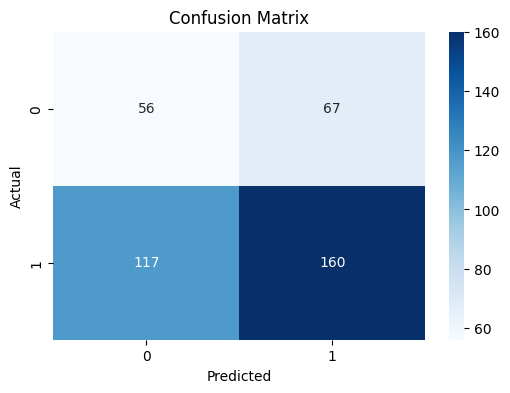

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance

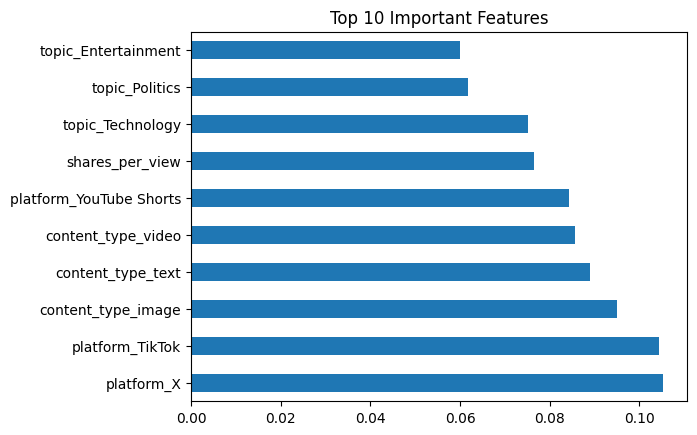

In [87]:
import matplotlib.pyplot as plt
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [88]:
y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.4
y_pred_new = (y_prob >= threshold).astype(int)
from sklearn.metrics import classification_report, accuracy_score
print("New Accuracy:", accuracy_score(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

New Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.36      0.17      0.23       123
           1       0.70      0.86      0.77       277

    accuracy                           0.65       400
   macro avg       0.53      0.52      0.50       400
weighted avg       0.59      0.65      0.61       400



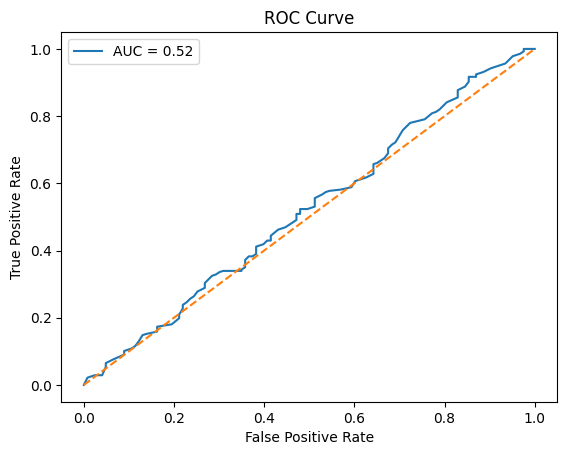

In [89]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

which content type works better

In [90]:
df.groupby("content_type")["is_viral"].mean()

,is_viral
content_type,
carousel,0.721591
image,0.687500
text,0.659836
video,0.726695


RESULTS

Model Performance Summary

Initial model showed 100% accuracy, which indicated data leakage

After removing leakage features:
Accuracy reduced to ~53–54% (realistic baseline)

After threshold tuning:
Accuracy improved to ~65%
But with reduced performance for minority class

In [92]:
df.to_csv("final_processed_dataset.csv", index=False)